# 07 — YOLOv8 Training & Inference for ROI Detection

Trains YOLOv8 on the YOLO-format dataset built in notebook 06, then runs inference and saves the best model for comparison in notebook 08.

> **Runtime:** Make sure you have selected **GPU** (Runtime → Change runtime type → T4 GPU).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/ROI_Endoscopy_Paper')
print('Working directory:', os.getcwd())

Working directory: /content/drive/MyDrive/ROI_Endoscopy_Paper


In [ ]:
!pip install -q ultralytics
print('ultralytics installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.5 MB/s eta 0:00:00
ultralytics installed.


In [ ]:
from ultralytics import YOLO
import torch, cv2, random, os
import matplotlib.pyplot as plt
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ── EDIT THESE PATHS ─────────────────────────────────────────────────────────
YOLO_DATA_DIR = '/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_dataset'
YOLO_RUNS_DIR = '/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_runs'
MODELS_DIR    = '/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_models'
# ─────────────────────────────────────────────────────────────────────────────

YAML_PATH = os.path.join(YOLO_DATA_DIR, 'data.yaml')

os.makedirs(YOLO_RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,    exist_ok=True)

assert os.path.exists(YAML_PATH), f'data.yaml not found at {YAML_PATH}. Run notebook 06 first!'
print('data.yaml found ✅')

data.yaml found ✅


In [ ]:
# yolov8n = nano  (fastest, less accurate)
# yolov8s = small
# yolov8m = medium  ← default here
# yolov8l = large
MODEL_SIZE = 'yolov8m.pt'

model = YOLO(MODEL_SIZE)
print(f'Loaded pretrained {MODEL_SIZE}')

Loaded pretrained yolov8m.pt


In [ ]:
# ── TRAINING ─────────────────────────────────────────────────────────────────
# Reduce batch to 8 if you get CUDA out‑of‑memory errors

results = model.train(
    data          = YAML_PATH,
    epochs        = 50,
    imgsz         = 640,
    batch         = 16,
    device        = 0 if DEVICE == 'cuda' else 'cpu',
    patience      = 10,
    save          = True,
    project       = YOLO_RUNS_DIR,
    name          = 'roi_detection',
    exist_ok      = True,
    optimizer     = 'SGD',
    lr0           = 0.01,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    warmup_epochs = 3,
    amp           = True
)

print('\n✅ Training complete!')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roi_detection, nbs=64, nms=False, opset=None, optimize=False, optimize

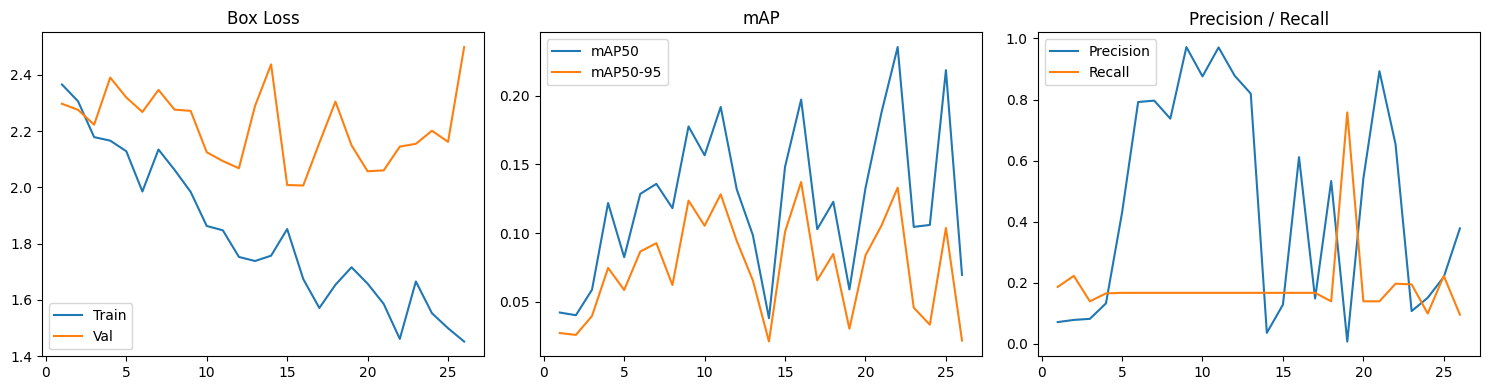

In [ ]:
import pandas as pd

csv_path = os.path.join(YOLO_RUNS_DIR, 'roi_detection', 'results.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axes[0].plot(df['epoch'], df['val/box_loss'],   label='Val')
    axes[0].set_title('Box Loss'); axes[0].legend()

    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP50')
    axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50‑95')
    axes[1].set_title('mAP'); axes[1].legend()

    axes[2].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axes[2].plot(df['epoch'], df['metrics/recall(B)'],    label='Recall')
    axes[2].set_title('Precision / Recall'); axes[2].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(YOLO_RUNS_DIR, 'training_curves.png'), dpi=150)
    plt.show()
else:
    print('results.csv not found — training may still be running.')

In [ ]:
BEST_MODEL = os.path.join(YOLO_RUNS_DIR, 'roi_detection', 'weights', 'best.pt')
model_best = YOLO(BEST_MODEL)

val_results = model_best.val(data=YAML_PATH)

print('\n=== Validation Metrics ===')
print(f'mAP@50      : {val_results.box.map50:.4f}')
print(f'mAP@50‑95   : {val_results.box.map:.4f}')
print(f'Precision   : {val_results.box.mp:.4f}')
print(f'Recall      : {val_results.box.mr:.4f}')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 77.8±35.2 MB/s, size: 191.6 KB)
val: Scanning /content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_dataset/labels/val.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all         13         17      0.611      0.167      0.198      0.137
                 polyp          6          6          0          0     0.0331     0.0141
                lesion          4          7          1          0     0.0377     0.0205
          inflammation          4          4      0.832        0.5      0.522      0.376
Speed: 1.4ms preprocess, 26.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /conten

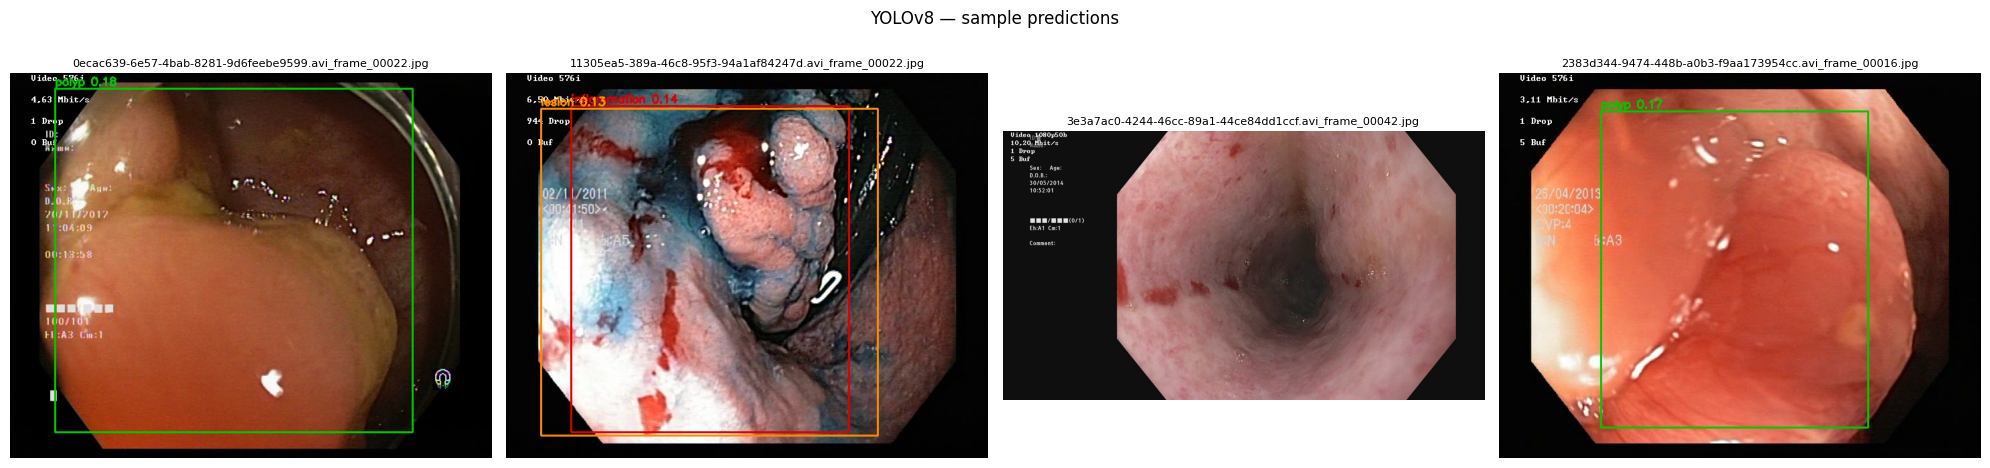

In [ ]:
CLASS_NAMES = {0: 'polyp', 1: 'lesion', 2: 'inflammation'}
COLORS      = {'polyp': (0,200,0), 'lesion': (255,140,0), 'inflammation': (220,0,0)}

val_img_dir = os.path.join(YOLO_DATA_DIR, 'images', 'val')
val_imgs    = [f for f in os.listdir(val_img_dir) if f.endswith(('.jpg', '.png'))]
random.seed(0)
samples = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, img_name in zip(axes, samples):
    img_path = os.path.join(val_img_dir, img_name)
    img      = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    preds    = model_best.predict(source=img_path, conf=0.1, verbose=False)[0]

    for box in preds.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        cls  = int(box.cls[0])
        conf = box.conf[0].item()
        name = CLASS_NAMES.get(cls, 'unknown')
        col  = COLORS.get(name, (255,255,255))
        cv2.rectangle(img, (x1,y1), (x2,y2), col, 2)
        cv2.putText(img, f'{name} {conf:.2f}', (x1, max(y1-5,15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)

    ax.imshow(img)
    ax.set_title(img_name, fontsize=8)
    ax.axis('off')

plt.suptitle('YOLOv8 — sample predictions', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(YOLO_RUNS_DIR, 'sample_predictions.png'), dpi=150)
plt.show()

In [ ]:
import shutil

save_path = os.path.join(MODELS_DIR, 'yolov8_roi_best.pt')
shutil.copy(BEST_MODEL, save_path)
print(f'Best model copied to: {save_path}')

# Optional: export to ONNX for deployment
# model_best.export(format='onnx', imgsz=640)
print('\nDone! Use this model path in notebook 08:')
print(save_path)

Best model copied to: /content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_models/yolov8_roi_best.pt

Done! Use this model path in notebook 08:
/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_models/yolov8_roi_best.pt
